# Bamberg-Rig v5: Target-Zoom (57/59/61) + Shuffle-Control + Report

**Hinweis:** Dieses Notebook benötigt den **SageMath-Kernel**.

In [1]:
from sage.all import *
import numpy as np
import matplotlib.pyplot as plt

# Quaternion-Algebra (Bamberg-Rig)
H = QuaternionAlgebra(RR, -1, -1)
i, j, k = H.gens()
one = H(1)

## 0) Hilfsfunktionen

In [2]:
def make_ts_zoom(centers, halfwidth=0.25, step=0.001, t_min=0.0):
    """
    centers: list of floats
    returns unique sorted t-grid around each center
    """
    chunks = []
    for c in centers:
        a = max(t_min, c - halfwidth)
        b = c + halfwidth
        chunks.append(np.arange(a, b + 1e-12, step))
    return np.unique(np.concatenate(chunks))

def make_sigmas_zoom(center=0.5, halfwidth=0.18, step=0.002):
    s = np.arange(center - halfwidth, center + halfwidth + 1e-12, step)
    return s[(s >= 0.0) & (s <= 1.0)]

def scan_grid(func, sigmas, ts):
    A = np.zeros((len(ts), len(sigmas)), dtype=float)
    for it, t in enumerate(ts):
        for isg, sg in enumerate(sigmas):
            A[it, isg] = func(sg, t)
    return A

def show_heatmap(A, sigmas, ts, title):
    plt.figure()
    plt.imshow(A, aspect='auto', origin='lower',
               extent=[sigmas[0], sigmas[-1], ts[0], ts[-1]])
    plt.xlabel('sigma')
    plt.ylabel('t')
    plt.title(title)
    plt.colorbar()
    plt.show()

def min_over_sigma(A):
    return np.min(A, axis=1)

def find_local_windows_by_quantile(m, ts, q=0.02, min_run=20):
    """
    m: array over t (e.g. min_sigma log D)
    threshold by quantile, then return contiguous windows with length>=min_run
    """
    thr = np.quantile(m, q)
    good = (m <= thr)
    windows = []
    start = None
    for idx, g in enumerate(good):
        if g and start is None:
            start = idx
        if (not g) and (start is not None):
            end = idx - 1
            if end - start + 1 >= min_run:
                seg = m[start:end+1]
                windows.append((float(ts[start]), float(ts[end]),
                                float(np.min(seg)), float(np.median(seg))))
            start = None
    if start is not None:
        end = len(good)-1
        if end - start + 1 >= min_run:
            seg = m[start:end+1]
            windows.append((float(ts[start]), float(ts[end]),
                            float(np.min(seg)), float(np.median(seg))))
    windows.sort(key=lambda x: x[2])  # sort by min
    return windows, float(thr)

## 1) Shuffle-Control: permutiere E/A/B/C-Basis pro Prime

In [3]:
def build_prime_basis_map(P=3000, seed=0, include_2_3=False):
    """
    Erzeugt eine feste Zuordnung prime -> Quaternion-Basis u(p)
    nach deiner E/A/B/C mod12-Regel (Original).
    """
    mp = {}
    for p in prime_range(2, P+1):
        if (p in [2,3]) and (not include_2_3):
            continue
        r = Integer(p) % 12
        if r == 1:
            mp[int(p)] = one
        elif r == 5:
            mp[int(p)] = i
        elif r == 7:
            mp[int(p)] = j
        elif r == 11:
            mp[int(p)] = k
        else:
            mp[int(p)] = one
    return mp

def shuffled_basis_map(original_map, seed=0):
    """
    Nullhypothese: gleiche primes, aber Basisrichtungen zufällig neu zugewiesen.
    Wir shuffeln die Liste der u(p)-Werte und hängen sie wieder an die primes.
    """
    rng = np.random.default_rng(seed)
    primes = np.array(sorted(original_map.keys()), dtype=int)
    vals = [original_map[int(p)] for p in primes]
    rng.shuffle(vals)
    return {int(p): vals[idx] for idx, p in enumerate(primes)}

## 2) Feld/DP/E/D mit injizierbarer Prime->Basis-Map

In [4]:
def weight_re_im(p, sigma, t, use_log=True):
    lp = float(np.log(p))
    amp = lp if use_log else 1.0
    mag = np.exp(-sigma*lp)
    phase = -t*lp
    w_re = amp * mag * np.cos(phase)
    w_im = amp * mag * np.sin(phase)
    return w_re, w_im

def Q_re_im_fields_with_map(sigma, t, prime_basis_map, use_log=True):
    Qre = H(0)
    Qim = H(0)
    for p, u in prime_basis_map.items():
        w_re, w_im = weight_re_im(p, sigma, t, use_log=use_log)
        Qre += (w_re * u)
        Qim += (w_im * (i*u))
    return Qre, Qim

def dot4(Qa, Qb):
    return float(Qa[0]*Qb[0] + Qa[1]*Qb[1] + Qa[2]*Qb[2] + Qa[3]*Qb[3])

def double_product_term_with_map(sigma, t, prime_basis_map, use_log=True):
    Qre, Qim = Q_re_im_fields_with_map(sigma, t, prime_basis_map, use_log=use_log)
    return float(2.0 * dot4(Qre, Qim))

def energy_with_map(sigma, t, prime_basis_map, use_log=True, lam=0.25):
    Qre, Qim = Q_re_im_fields_with_map(sigma, t, prime_basis_map, use_log=use_log)
    Q = Qre + Qim
    E0 = float(Q.reduced_norm())
    DP = abs(double_product_term_with_map(sigma, t, prime_basis_map, use_log=use_log))
    return E0 + lam*DP

def symmetry_defect_with_map(sigma, t, prime_basis_map, use_log=True, lam=0.25):
    return abs(energy_with_map(sigma, t, prime_basis_map, use_log=use_log, lam=lam)
               - energy_with_map(1.0 - sigma, t, prime_basis_map, use_log=use_log, lam=lam))

## 3) v5 Runner

In [5]:
def run_v5(P=3000, lam=0.25, use_log=True,
           centers=None,
           t_halfwidth=0.25, t_step=0.001,
           sigma_halfwidth=0.18, sigma_step=0.002,
           q=0.02, min_run=20,
           n_shuffle=30, seed0=123):
    if centers is None:
        centers = [57.0, 59.0, 61.0]

    ts_zoom = make_ts_zoom(centers, halfwidth=t_halfwidth, step=t_step, t_min=0.0)
    sigmas_zoom = make_sigmas_zoom(center=0.5, halfwidth=sigma_halfwidth, step=sigma_step)

    print("\n=== v5 Target-Zoom ===")
    print(f"P={P}, lam={lam}, use_log={use_log}")
    print(f"centers={centers}, t_step={t_step}, window=±{t_halfwidth}")
    print(f"sigmas: [{sigmas_zoom[0]:.3f}, {sigmas_zoom[-1]:.3f}] step={sigma_step}")
    print(f"grid: |ts|={len(ts_zoom)}  |sigmas|={len(sigmas_zoom)}")

    base_map = build_prime_basis_map(P=P, seed=seed0)

    eps0 = 1e-30
    print("Scanning ORIGINAL Dlog / DPlog ...")
    Dlog = scan_grid(lambda sg,t: np.log(symmetry_defect_with_map(sg,t,base_map,use_log=use_log,lam=lam)+eps0),
                     sigmas_zoom, ts_zoom)
    DPlog = scan_grid(lambda sg,t: np.log(abs(double_product_term_with_map(sg,t,base_map,use_log=use_log))+eps0),
                      sigmas_zoom, ts_zoom)

    mD = min_over_sigma(Dlog)
    mDP = min_over_sigma(DPlog)
    corr = float(np.corrcoef(mD, mDP)[0,1])
    print(f"Driver corr (min_sigma logD vs min_sigma log|DP|): {corr:.4f}")

    windows, thr = find_local_windows_by_quantile(mD, ts_zoom, q=q, min_run=min_run)
    print(f"Quantile threshold q={q}: thr={thr:.6f}")
    print("Top ORIGINAL windows (t0,t1,min,median):")
    for w in windows[:8]:
        print(f"  [{w[0]:.6f}, {w[1]:.6f}]  min={w[2]:.6f}  med={w[3]:.6f}")
    if not windows:
        print("  (keine stabilen Fenster bei diesen Parametern)")

    show_heatmap(Dlog, sigmas_zoom, ts_zoom, f'v5: log D(sigma,t) ORIGINAL (lam={lam})')
    show_heatmap(DPlog, sigmas_zoom, ts_zoom, 'v5: log |DP(sigma,t)| ORIGINAL')

    plt.figure()
    plt.plot(ts_zoom, mD)
    plt.xlabel('t')
    plt.ylabel('min_sigma log D')
    plt.title('v5: min_sigma log D (ORIGINAL)')
    plt.show()

    plt.figure()
    plt.plot(ts_zoom, mDP)
    plt.xlabel('t')
    plt.ylabel('min_sigma log |DP|')
    plt.title('v5: min_sigma log |DP| (ORIGINAL)')
    plt.show()

    it_best = int(np.argmin(mD))
    t_best = float(ts_zoom[it_best])
    print(f"\nBest t (ORIGINAL): t_best={t_best:.6f}  min_sigma logD={mD[it_best]:.6f}")

    Dsig = np.array([symmetry_defect_with_map(sg, t_best, base_map, use_log=use_log, lam=lam) for sg in sigmas_zoom])
    DPsig = np.array([abs(double_product_term_with_map(sg, t_best, base_map, use_log=use_log)) for sg in sigmas_zoom])

    plt.figure()
    plt.plot(sigmas_zoom, np.log(Dsig + eps0))
    plt.axvline(0.5)
    plt.xlabel('sigma')
    plt.ylabel('log D(sigma,t_best)')
    plt.title(f'v5: Sigma-Profil log D bei t_best={t_best:.6f} (ORIGINAL)')
    plt.show()

    plt.figure()
    plt.plot(sigmas_zoom, np.log(DPsig + eps0))
    plt.axvline(0.5)
    plt.xlabel('sigma')
    plt.ylabel('log |DP(sigma,t_best)|')
    plt.title(f'v5: Sigma-Profil log |DP| bei t_best={t_best:.6f} (ORIGINAL)')
    plt.show()

    print(f"\nRunning SHUFFLE control (n={n_shuffle}) ...")
    mins = []
    best_ts = []
    for s in range(n_shuffle):
        sh_map = shuffled_basis_map(base_map, seed=seed0 + 1000 + s)
        Dlog_sh = scan_grid(lambda sg,t: np.log(symmetry_defect_with_map(sg,t,sh_map,use_log=use_log,lam=lam)+eps0),
                            sigmas_zoom, ts_zoom)
        mD_sh = min_over_sigma(Dlog_sh)
        mins.append(float(np.min(mD_sh)))
        best_ts.append(float(ts_zoom[int(np.argmin(mD_sh))]))

    mins = np.array(mins, dtype=float)
    mu = float(np.mean(mins))
    sd = float(np.std(mins, ddof=1)) if n_shuffle > 1 else float('nan')
    z = float((mD[it_best] - mu) / (sd + 1e-12)) if n_shuffle > 1 else float('nan')

    print("\n=== Mini-Report (ORIGINAL vs SHUFFLE) ===")
    print(f"Observed best min_sigma logD : {mD[it_best]:.6f} at t={t_best:.6f}")
    print(f"Shuffle baseline mean(best) : {mu:.6f}")
    print(f"Shuffle baseline std(best)  : {sd:.6f}")
    print(f"Z-score (lower is better!)   : {z:.3f}")
    print(f"Shuffle best-t mean/std      : {float(np.mean(best_ts)):.4f} / {float(np.std(best_ts, ddof=1)):.4f}")

    plt.figure()
    plt.hist(mins, bins=12)
    plt.axvline(mD[it_best])
    plt.xlabel('shuffle: min over t of (min_sigma logD)')
    plt.ylabel('count')
    plt.title('v5: Shuffle baseline distribution (vertical line = observed)')
    plt.show()

    return {
        "t_best": t_best,
        "minlogD_best": float(mD[it_best]),
        "driver_corr": corr,
        "windows": windows[:8],
        "shuffle_mean": mu,
        "shuffle_std": sd,
        "zscore_lower_better": z
    }

## Ausführung


=== v5 Target-Zoom ===
P=3000, lam=0.250000000000000, use_log=True
centers=[57.0000000000000, 59.0000000000000, 61.0000000000000], t_step=0.00100000000000000, window=±0.250000000000000
sigmas: [0.320, 0.680] step=0.00200000000000000
grid: |ts|=1503  |sigmas|=181
Scanning ORIGINAL Dlog / DPlog ...
Driver corr (min_sigma logD vs min_sigma log|DP|): -0.1204
Quantile threshold q=0.0200000000000000: thr=-31.479305
Top ORIGINAL windows (t0,t1,min,median):
  (keine stabilen Fenster bei diesen Parametern)


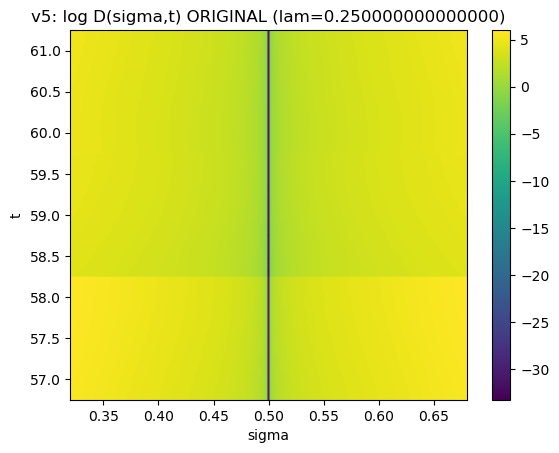

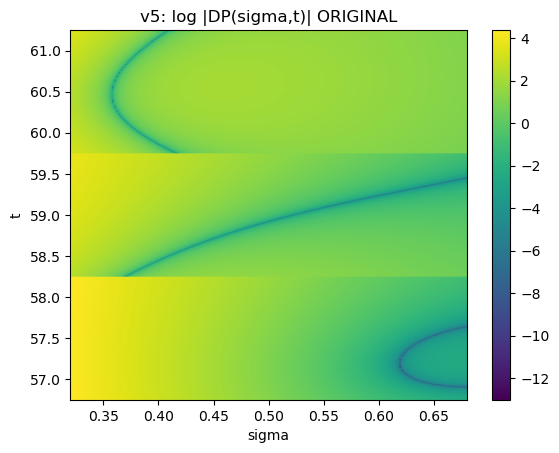

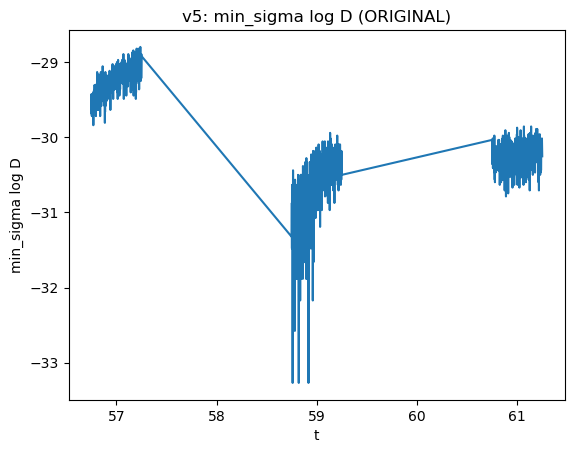

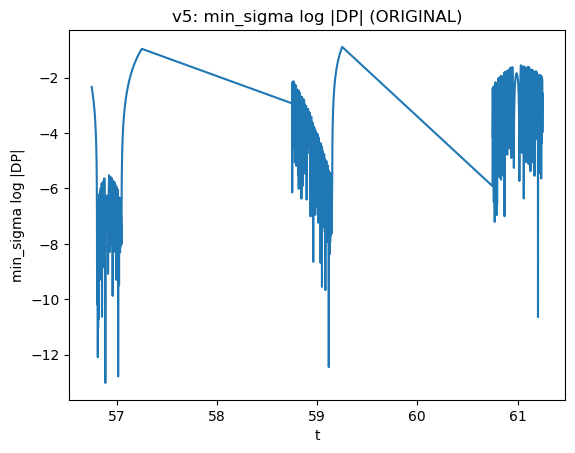


Best t (ORIGINAL): t_best=58.759000  min_sigma logD=-33.271065


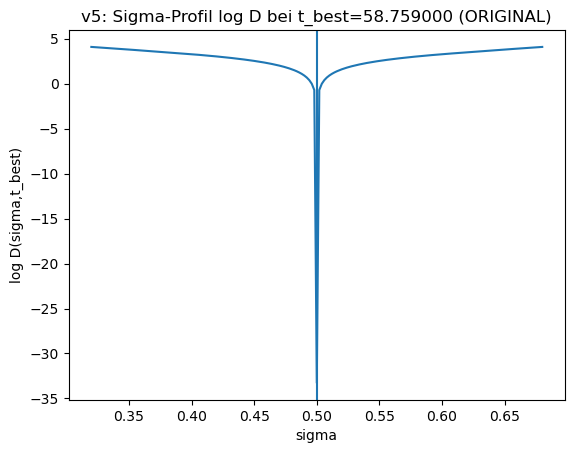

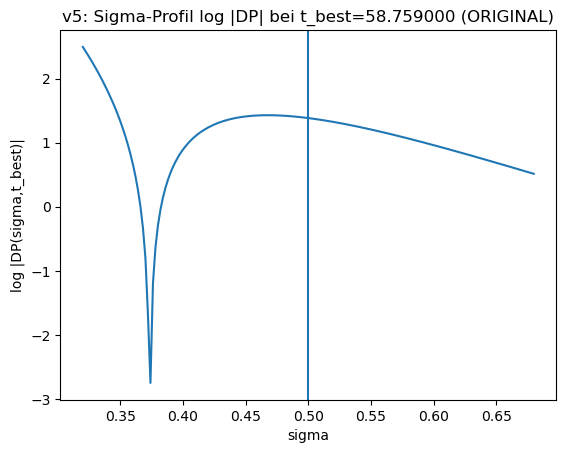


Running SHUFFLE control (n=30) ...


TypeError: SeedSequence expects int or sequence of ints for entropy not 1123

In [6]:
out = run_v5(P=3000, lam=0.25, centers=[57.0, 59.0, 61.0],
             t_halfwidth=0.25, t_step=0.001,
             sigma_halfwidth=0.18, sigma_step=0.002,
             q=0.02, min_run=20, n_shuffle=30, seed0=123)